In [1]:
#import statements
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import matplotlib.pyplot as plt
from torchinfo import summary
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, r2_score
from sklearn.preprocessing import label_binarize
from pathlib import Path
from scipy import signal

In [2]:
from lightning_scaffold import (
    EEGDataModule,
    EEGRegressionLightningModule,
    MetricsCollector,
    ResNet1D,
    build_trainer,
    tensorboard_logdir,
)

In [5]:
pca_vals = pd.read_parquet('model_data/matched_pca_vectors.parquet')

In [4]:
class CustomDataLoader(Dataset):
    def __init__(self, eeg_dir, pca_vals, n_pca=10, pca_start=0, n_segments=1, dtype=torch.float32, 
                 normalize_targets=True, target_mean=None, target_std=None):
        self.eeg_dir = Path(eeg_dir)
        self.n_pca = n_pca
        self.pca_start = pca_start
        self.n_segments = n_segments
        self.dtype = dtype
        self.normalize_targets = normalize_targets

        # subject -> PCA target
        self.subject_to_pca = {}
        all_vectors = []
        for _, row in pca_vals.iterrows():
            subj = str(row['subject'])
            vec = np.asarray(row['vector'], dtype=np.float32)
            if vec.shape[0] >= pca_start + n_pca:
                vec_slice = vec[pca_start : pca_start + n_pca]
                self.subject_to_pca[subj] = vec_slice
                all_vectors.append(vec_slice)

        # Compute robust target normalization statistics (median/IQR)
        # Use median/IQR to reduce impact of extreme outliers (skew=3.14, max=14σ)
        if normalize_targets and len(all_vectors) > 0:
            all_vectors = np.array(all_vectors)
            if target_mean is None:
                self.target_mean = np.median(all_vectors, axis=0, keepdims=True)
                q75 = np.percentile(all_vectors, 75, axis=0, keepdims=True)
                q25 = np.percentile(all_vectors, 25, axis=0, keepdims=True)
                iqr = q75 - q25
                # Scale by IQR/1.35 ≈ std for normal distribution
                self.target_std = (iqr / 1.35) + 1e-8
            else:
                self.target_mean = target_mean
                self.target_std = target_std
        else:
            self.target_mean = None
            self.target_std = None

        # subjects that have EEG parquet
        self.subjects = [
            subj for subj in self.subject_to_pca
            if (self.eeg_dir / f"{subj}.parquet").exists() ]

    def __len__(self):
        return len(self.subjects)
    
    def _fix_len(self, x: np.ndarray) -> np.ndarray:
        """Crop or zero-pad 1D array to self.segment_len."""
        x = np.asarray(x, dtype=np.float32).ravel()
        L = x.shape[0]
        if L == 2560:
            return x
        if L > 2560:
            return x[:2560]
        # pad
        out = np.zeros(2560, dtype=np.float32)
        out[:L] = x
        return out
    
    def __getitem__(self, idx):
        subject_id = self.subjects[idx]
        # target
        y = np.asarray(self.subject_to_pca[subject_id], dtype=np.float32)
        
        # Normalize targets if enabled
        if self.normalize_targets and self.target_mean is not None:
            y = (y - self.target_mean.flatten()) / self.target_std.flatten()
            # Clip extreme outliers to ±5 after normalization
            y = np.clip(y, -5.0, 5.0)
        
        y = torch.tensor(y, dtype=self.dtype)
        # EEG
        df = pd.read_parquet(self.eeg_dir / f"{subject_id}.parquet")

        # --- Select the first n_segments that actually exist (segment_index may start at 176, etc.)
        seg_ids = np.sort(df['segment_index'].unique())
        chosen = seg_ids[: self.n_segments]
        df = df[df['segment_index'].isin(chosen)]

        # channel order from the first chosen segment
        first_seg = chosen[0]
        first_block = df[df['segment_index'] == first_seg]
        channels = first_block['channel_name'].astype(str).tolist()[:8]

        per_channel = []
        for ch in channels:
            ch_df = df[df['channel_name'].astype(str) == ch].sort_values('segment_index')
            ch_df = ch_df.iloc[: self.n_segments]
            
            segs = [self._fix_len(v) for v in ch_df['segment'].values]
            concat = np.concatenate(segs)
            # Ensure consistent size by tiling if fewer segments available
            expected_len = 2560 * self.n_segments
            if len(concat) < expected_len:
                repeats = int(np.ceil(expected_len / len(concat)))
                concat = np.tile(concat, repeats)[:expected_len]
            per_channel.append(concat)

        X = np.stack(per_channel)  # (8, 2560*n_segments)
        
        # Per-subject z-score normalization of EEG inputs
        # Standardize each subject's EEG to mean=0, std=1 across all channels and time
        x_mean = X.mean()
        x_std = X.std() + 1e-8  # avoid division by zero
        X = (X - x_mean) / x_std
        
        X = torch.tensor(X, dtype=self.dtype)
        return X, y

In [ ]:
N_COMPONENTS = 10
PLOT_DIR = Path("model_data/component_results")

results = {}

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



  Training component 0




  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.6406850814819336
         test_r2           -0.08455178886651993
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


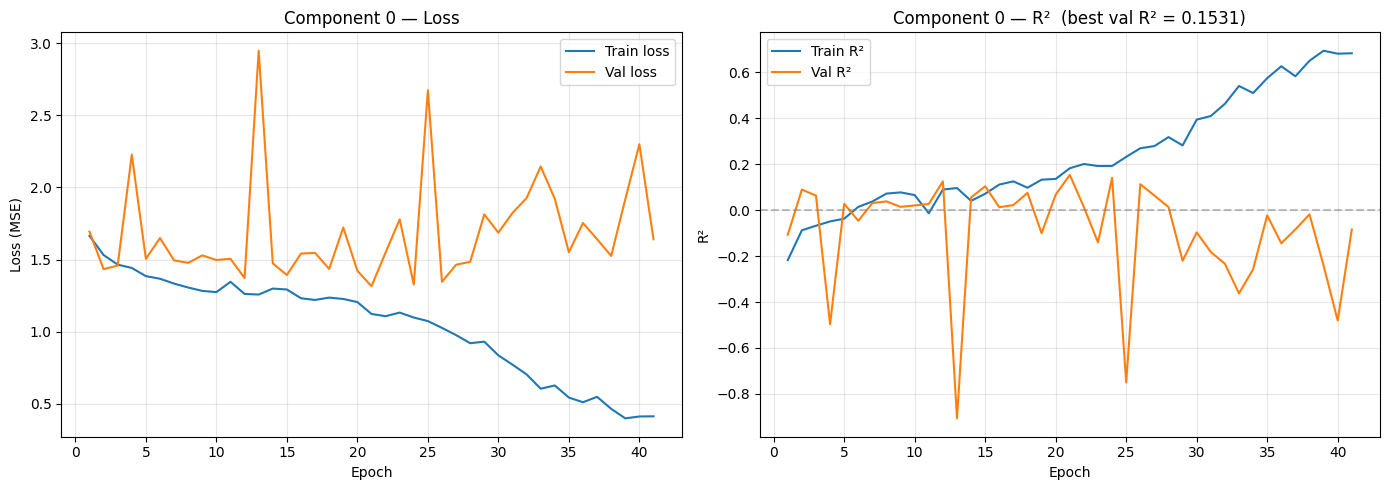

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 0: best val R² = 0.1531, test R² = -0.0846, test loss = 1.6407

  Training component 1



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.4040179252624512
         test_r2           0.012827196158468723
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


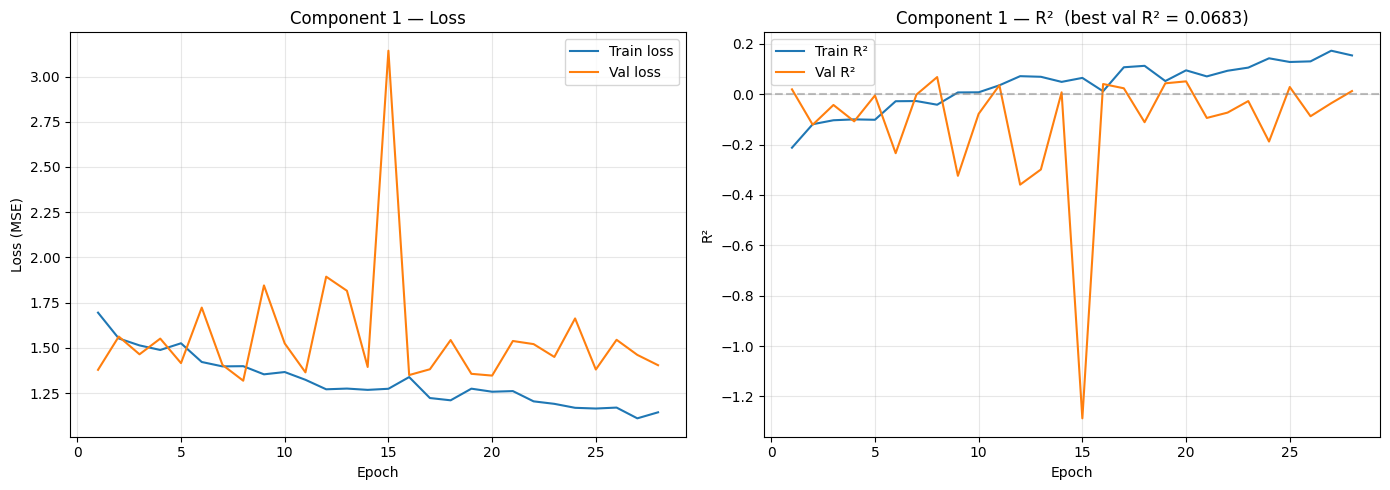

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 1: best val R² = 0.0683, test R² = 0.0128, test loss = 1.4040

  Training component 2



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss            1.833173394203186
         test_r2           -0.29302045702934265
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


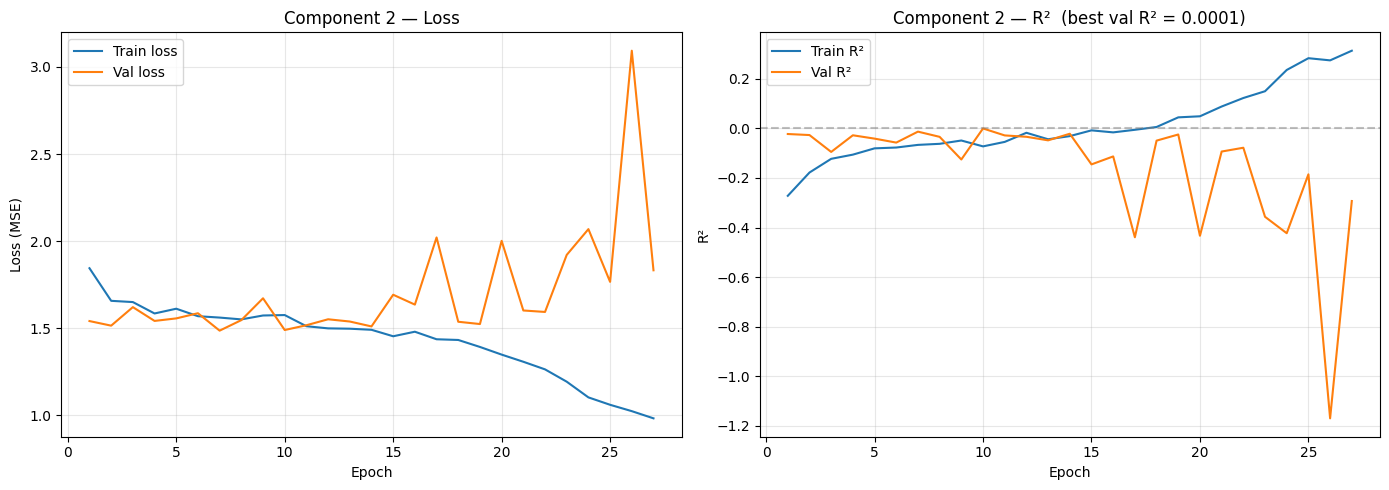

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 2: best val R² = 0.0001, test R² = -0.2930, test loss = 1.8332

  Training component 3



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss            2.021090269088745
         test_r2           -0.23122745752334595
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


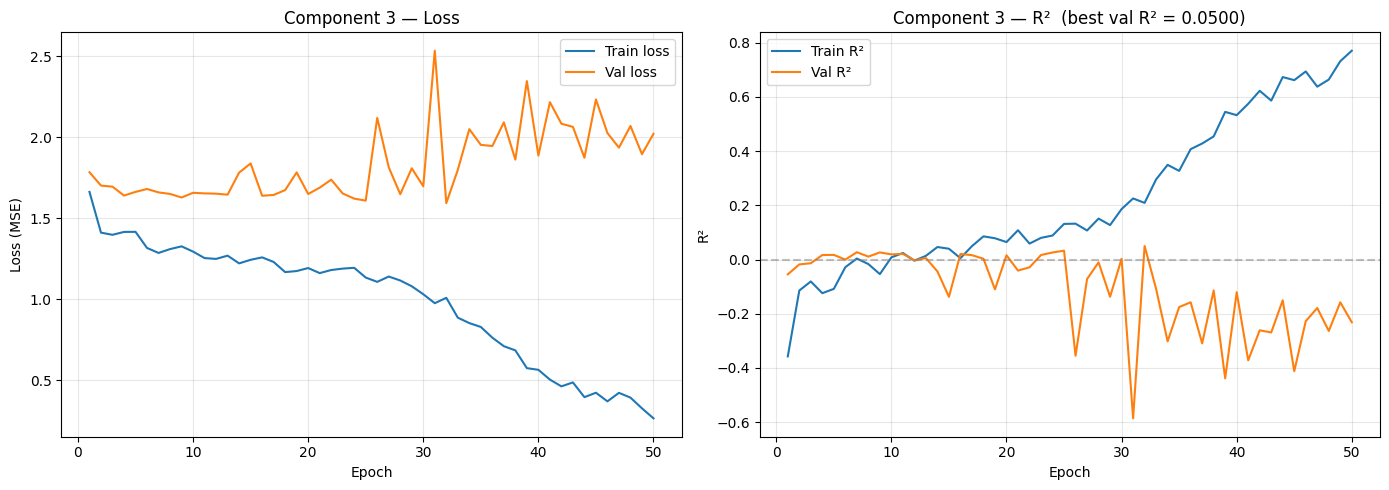

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 3: best val R² = 0.0500, test R² = -0.2312, test loss = 2.0211

  Training component 4



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.5012683868408203
         test_r2           -0.06506329774856567
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


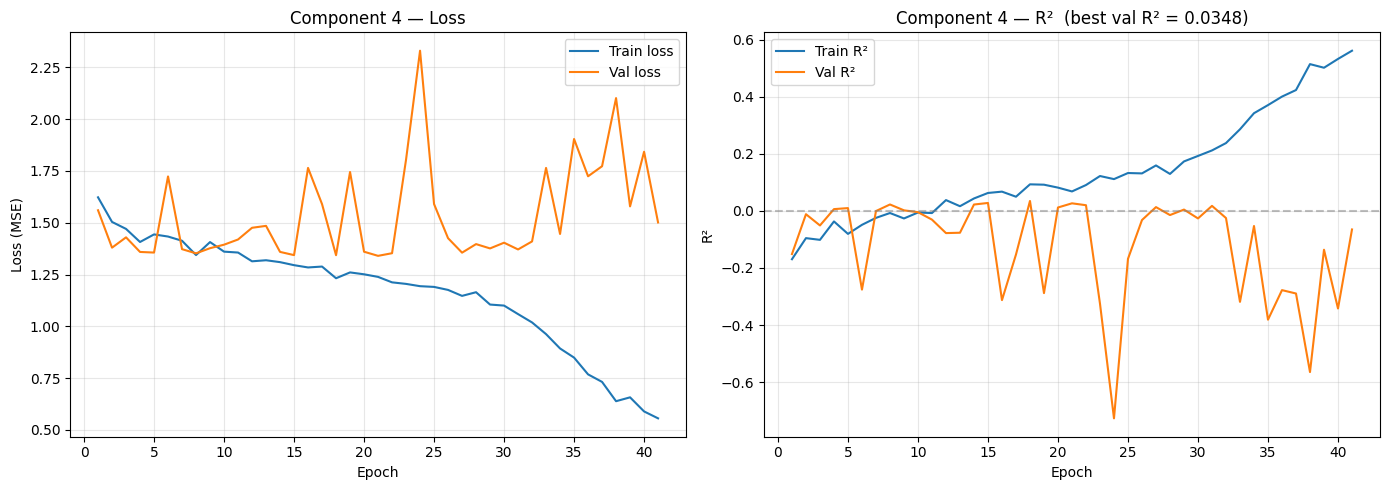

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 4: best val R² = 0.0348, test R² = -0.0651, test loss = 1.5013

  Training component 5



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.4771127700805664
         test_r2           -0.17296965420246124
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


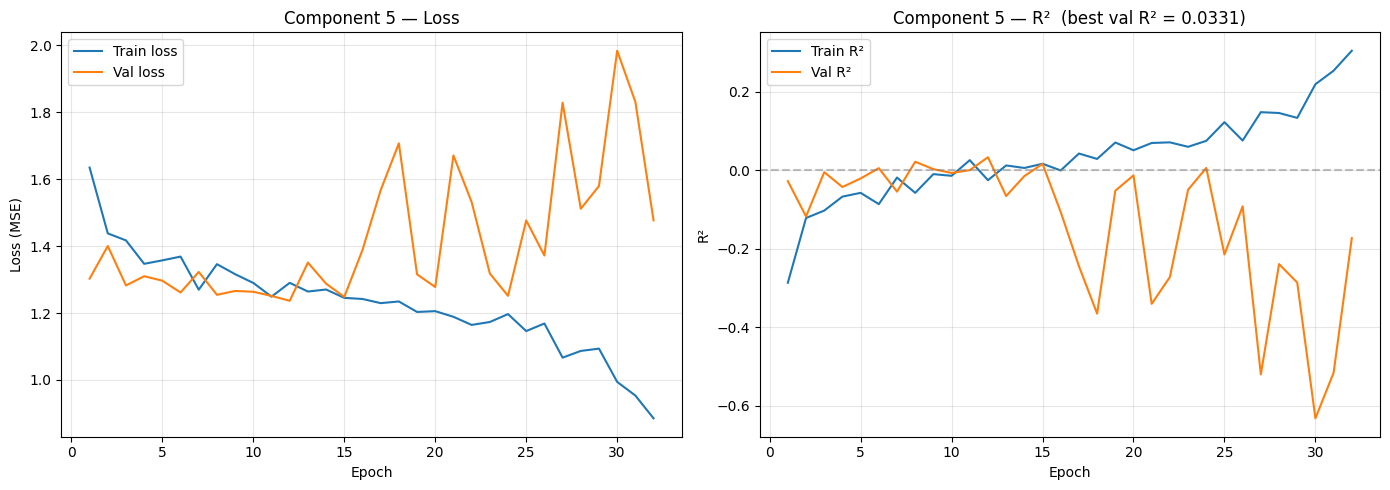

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 5: best val R² = 0.0331, test R² = -0.1730, test loss = 1.4771

  Training component 6



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.5260159969329834
         test_r2            -0.0780385434627533
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


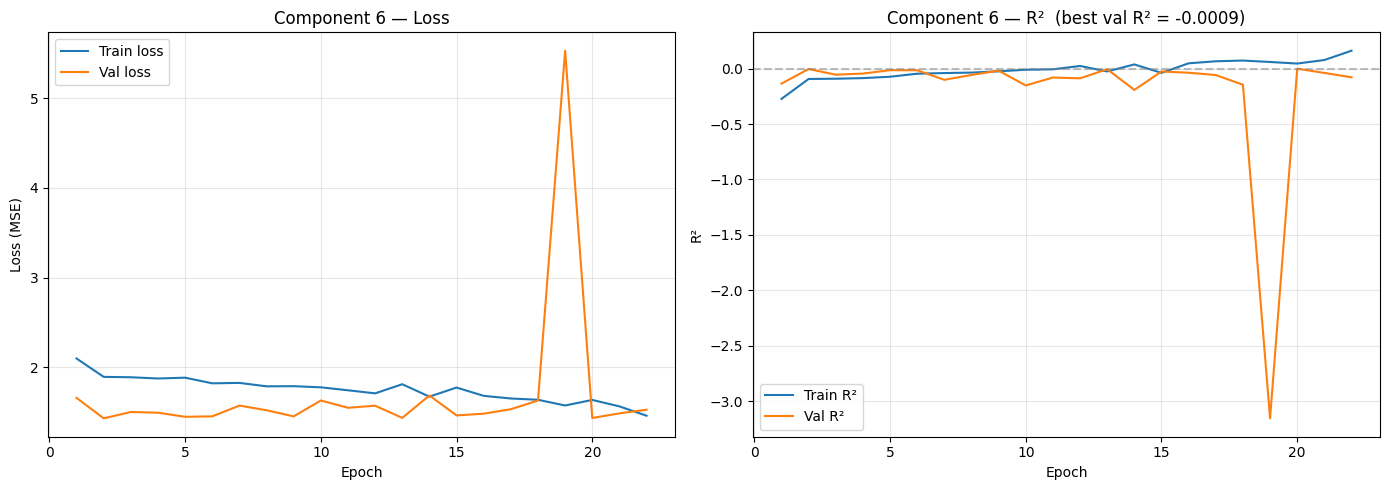

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 6: best val R² = -0.0009, test R² = -0.0780, test loss = 1.5260

  Training component 7



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           2.9438657760620117
         test_r2           -0.20602883398532867
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


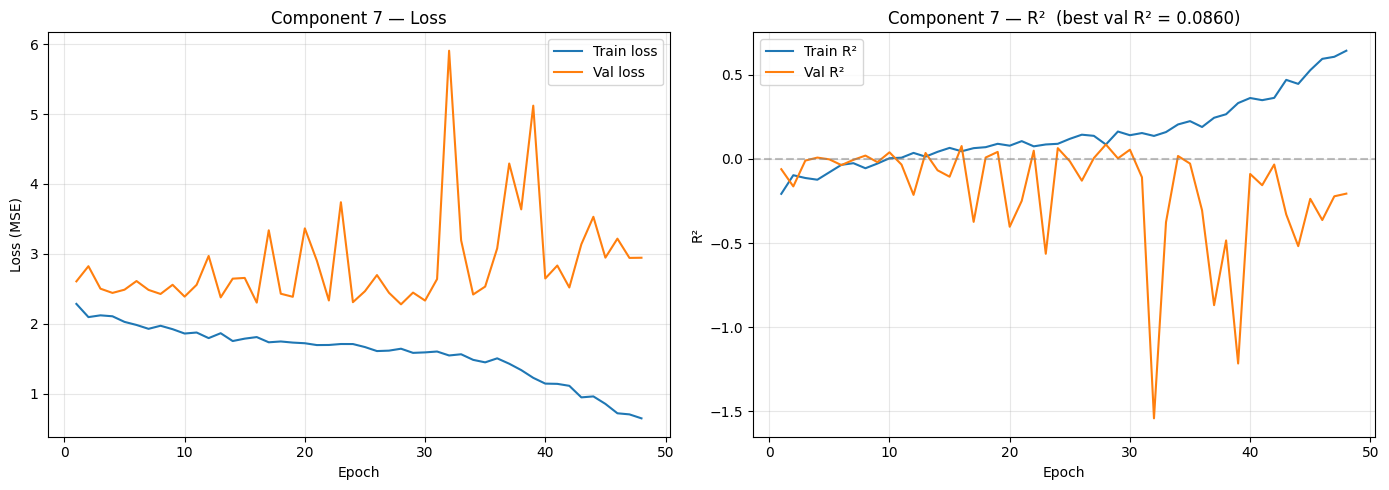

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 7: best val R² = 0.0860, test R² = -0.2060, test loss = 2.9439

  Training component 8



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           2.2473883628845215
         test_r2            -0.6547784209251404
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


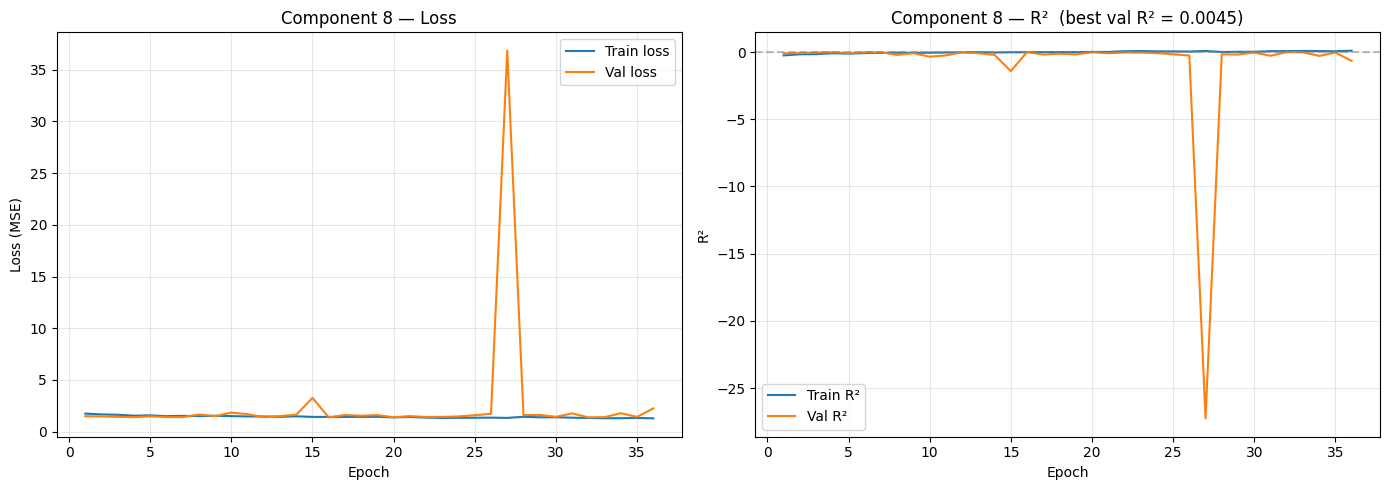

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 240 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
240 K     Trainable params
0         Non-trainable params
240 K     Total params
0.964     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Component 8: best val R² = 0.0045, test R² = -0.6548, test loss = 2.2474

  Training component 9



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           2.2005152702331543
         test_r2           -0.48251935839653015
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


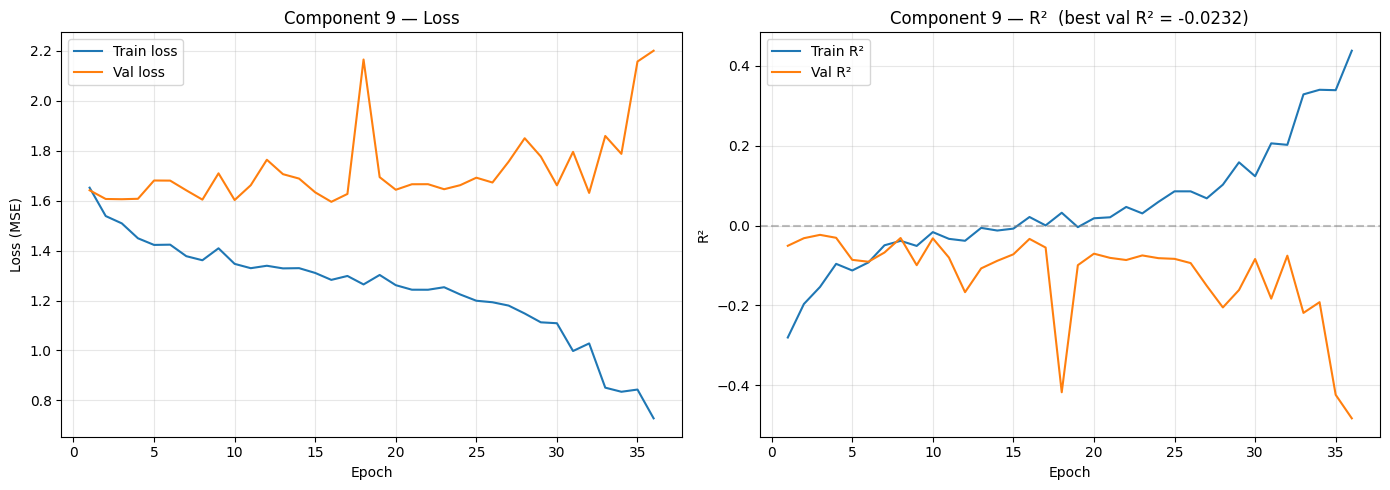

Component 9: best val R² = -0.0232, test R² = -0.4825, test loss = 2.2005


In [7]:
for comp in range(N_COMPONENTS):
    print(f"\n{'='*60}")
    print(f"  Training component {comp}")
    print(f"{'='*60}\n")

    dataset = CustomDataLoader(
        eeg_dir="model_data/filtered_glob_ref",
        pca_vals=pca_vals,
        n_pca=1,
        pca_start=comp,
        n_segments=10,
        normalize_targets=True,
    )

    base_model = ResNet1D(
        in_channels=8,
        n_outputs=1,
        base_channels=32,
        blocks_per_stage=(2, 2, 2),
        kernel_size=3,
        dropout=0.3,
    )

    lightning_model = EEGRegressionLightningModule(
        model=base_model,
        lr=1e-3,
        weight_decay=0.0,
        target_mean=getattr(dataset, "target_mean", None),
        target_std=getattr(dataset, "target_std", None),
    )

    data_module = EEGDataModule(
        dataset=dataset,
        batch_size=32,
        train_frac=0.8,
        random_state=42,
        num_workers=0,
        pin_memory=False,
    )

    bundle = build_trainer(
        run_name=f"resnet1d_comp{comp}",
        tb_root_dir="model_data/tb_logs",
        ckpt_dir=f"model_data/models/lightning/comp{comp}",
        max_epochs=50,
        monitor="val_loss",
        monitor_mode="min",
        early_stopping_patience=20,
    )

    bundle.trainer.fit(lightning_model, datamodule=data_module)
    test_results = bundle.trainer.test(lightning_model, datamodule=data_module)

    mc = bundle.metrics_collector
    best_val_r2 = max(mc.val_r2) if mc.val_r2 else float("nan")

    results[comp] = {
        "train_loss": mc.train_loss,
        "val_loss": mc.val_loss,
        "train_r2": mc.train_r2,
        "val_r2": mc.val_r2,
        "test_loss": test_results[0]["test_loss"],
        "test_r2": test_results[0]["test_r2"],
        "best_val_r2": best_val_r2,
        "best_ckpt": bundle.checkpoint_callback.best_model_path,
    }

    # --- Per-component plots ---
    epochs = range(1, len(mc.train_loss) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, mc.train_loss, label="Train loss")
    ax1.plot(epochs, mc.val_loss[:len(mc.train_loss)], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss (MSE)")
    ax1.set_title(f"Component {comp} — Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, mc.train_r2, label="Train R²")
    ax2.plot(epochs, mc.val_r2[:len(mc.train_r2)], label="Val R²")
    ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("R²")
    ax2.set_title(f"Component {comp} — R²  (best val R² = {best_val_r2:.4f})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"comp{comp}_curves.png", dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Component {comp}: best val R² = {best_val_r2:.4f}, "
          f"test R² = {results[comp]['test_r2']:.4f}, "
          f"test loss = {results[comp]['test_loss']:.4f}")

In [6]:
summary_df = pd.DataFrame({
    "Component": list(results.keys()),
    "Best Val R²": [r["best_val_r2"] for r in results.values()],
    "Test R²": [r["test_r2"] for r in results.values()],
    "Test Loss": [r["test_loss"] for r in results.values()],
}).set_index("Component")

print(summary_df.to_string())
print(f"\nOverall best: Component {summary_df['Best Val R²'].idxmax()} "
      f"with val R² = {summary_df['Best Val R²'].max():.4f}")

summary_df.to_csv(PLOT_DIR / "component_summary.csv")

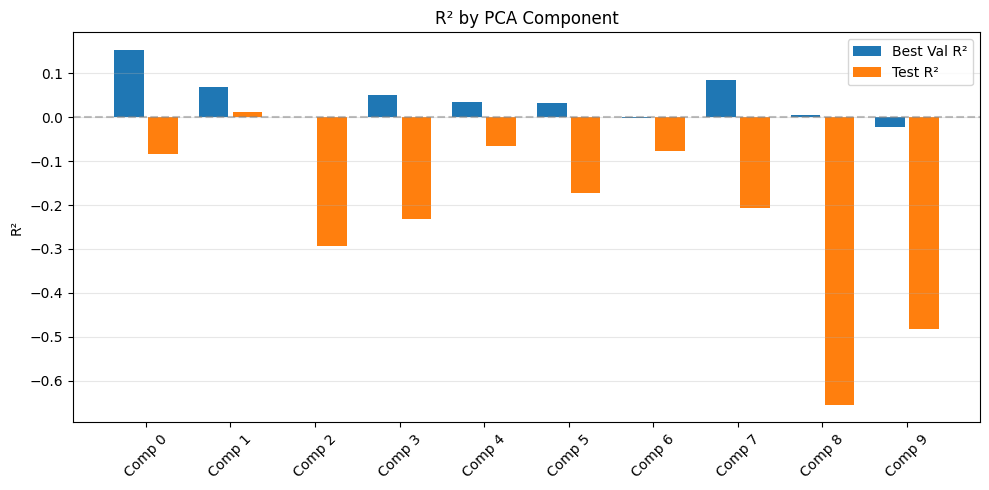

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
comps = list(results.keys())
val_r2s = [results[c]["best_val_r2"] for c in comps]
test_r2s = [results[c]["test_r2"] for c in comps]
x = np.arange(len(comps))
ax.bar(x - 0.2, val_r2s, 0.35, label="Best Val R²")
ax.bar(x + 0.2, test_r2s, 0.35, label="Test R²")
ax.set_xticks(x)
ax.set_xticklabels([f"Comp {c}" for c in comps], rotation=45)
ax.set_ylabel("R²")
ax.set_title("R² by PCA Component")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(PLOT_DIR / "all_components_r2.png", dpi=150)
plt.show()

In [14]:
dataset_1m = CustomDataLoader(
    eeg_dir="model_data/filtered_glob_ref",
    pca_vals=pca_vals,
    n_pca=1,
    pca_start=0,
    n_segments=10,
    normalize_targets=True,
)

base_model_1m = ResNet1D(
    in_channels=8,
    n_outputs=1,
    base_channels=64,
    blocks_per_stage=(2, 2, 2),
    kernel_size=3,
    dropout=0.3,
)

lightning_model_1m = EEGRegressionLightningModule(
    model=base_model_1m,
    lr=1e-3,
    weight_decay=0.0,
    target_mean=getattr(dataset_1m, "target_mean", None),
    target_std=getattr(dataset_1m, "target_std", None),
)

data_module_1m = EEGDataModule(
    dataset=dataset_1m,
    batch_size=32,
    train_frac=0.8,
    random_state=42,
    num_workers=0,
    pin_memory=False,
)

bundle_1m = build_trainer(
    run_name="resnet1d_1m_comp0",
    tb_root_dir="model_data/tb_logs",
    ckpt_dir="model_data/models/lightning/1m_comp0",
    max_epochs=50,
    monitor="val_loss",
    monitor_mode="min",
    early_stopping_patience=20,
)

bundle_1m.trainer.fit(lightning_model_1m, datamodule=data_module_1m)
test_results_1m = bundle_1m.trainer.test(lightning_model_1m, datamodule=data_module_1m)

mc_1m = bundle_1m.metrics_collector
print(f"\n1M model (comp 0) — test loss: {test_results_1m[0]['test_loss']:.4f}, "
      f"test R²: {test_results_1m[0]['test_r2']:.4f}")
print(f"Best val R²: {max(mc_1m.val_r2):.4f}")
print(f"Best checkpoint: {bundle_1m.checkpoint_callback.best_model_path}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | ResNet1D | 957 K  | train
1 | loss_fn | MSELoss  | 0      | train
---------------------------------------------
957 K     Trainable params
0         Non-trainable params
957 K     Total params
3.828     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.4861661195755005
         test_r2           0.043094612658023834
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

1M model (comp 0) — test loss: 1.4862, test R²: 0.0431
Best val R²: 0.1959
Best checkpoint: /Users/william.wakefield/PycharmProjects/Brain_Research_Proj/Mayo_EEG_FDG_project/model_data/models/lightning/1m_comp0/epoch=36-val_loss=1.2506-val_r2=0.1959.ckpt


In [15]:
test_results_1m = bundle_1m.trainer.test(lightning_model_1m, datamodule=data_module_1m)

/Users/william.wakefield/PycharmProjects/Brain_Research_Proj/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.4861661195755005
         test_r2           0.043094612658023834
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [16]:
mc_1m = bundle_1m.metrics_collector
print(f"\n1M model (comp 0) — test loss: {test_results_1m[0]['test_loss']:.4f}, "
      f"test R²: {test_results_1m[0]['test_r2']:.4f}")
print(f"Best val R²: {max(mc_1m.val_r2):.4f}")
print(f"Best checkpoint: {bundle_1m.checkpoint_callback.best_model_path}")


1M model (comp 0) — test loss: 1.4862, test R²: 0.0431
Best val R²: 0.1959
Best checkpoint: /Users/william.wakefield/PycharmProjects/Brain_Research_Proj/Mayo_EEG_FDG_project/model_data/models/lightning/1m_comp0/epoch=36-val_loss=1.2506-val_r2=0.1959.ckpt


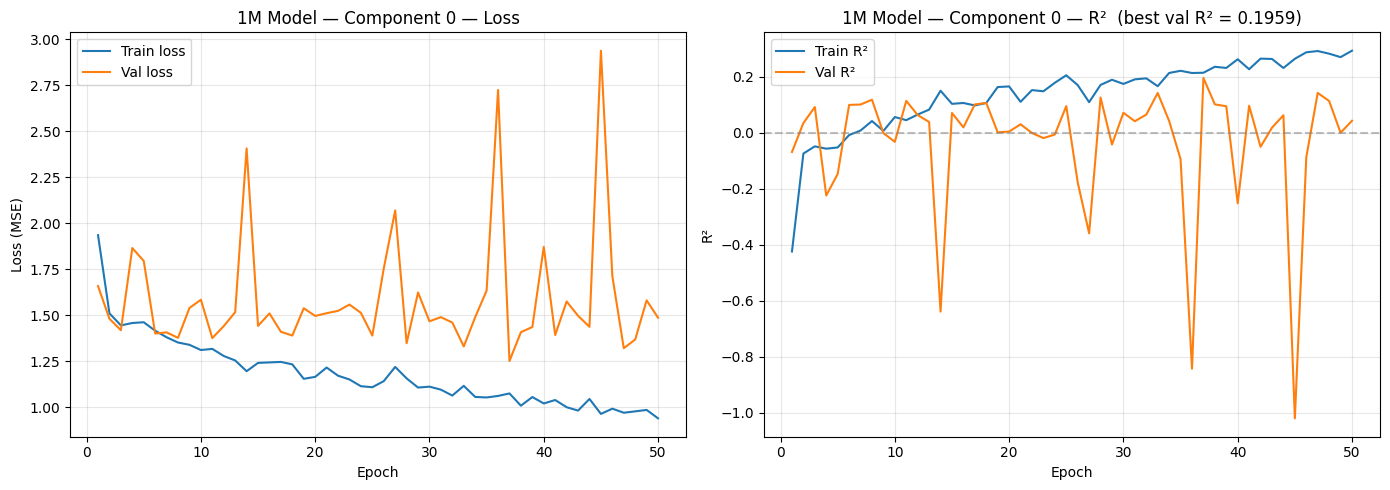

In [17]:
epochs_1m = range(1, len(mc_1m.train_loss) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_1m, mc_1m.train_loss, label="Train loss")
ax1.plot(epochs_1m, mc_1m.val_loss[:len(mc_1m.train_loss)], label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("1M Model — Component 0 — Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_1m, mc_1m.train_r2, label="Train R²")
ax2.plot(epochs_1m, mc_1m.val_r2[:len(mc_1m.train_r2)], label="Val R²")
ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("R²")
best_val_r2_1m = max(mc_1m.val_r2) if mc_1m.val_r2 else float("nan")
ax2.set_title(f"1M Model — Component 0 — R²  (best val R² = {best_val_r2_1m:.4f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()